In [2]:
import pandas as pd
import glob
import os
import sys
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr, pointbiserialr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sys.path.insert(0, r"C:\Users\fdora\RA_Career\Projects\climate_mortality")

from src.utils.d25_nb_utils import (
    autosave_fig, save_table,
)

base = r"C:\Users\fdora\RA_Career\Projects\climate_mortality\data\processed"

islands = {
    "tenerife":      "tfe",
    "gran_canaria":  "gcan",
    "lanzarote":     "lzt",
    "fuerteventura": "ftv",
    "la_palma":      "lpa",
    "gomera":        "gom",
}

# Verificar qué parquets existen por isla
for island, code in islands.items():
    island_path = os.path.join(base, island)
    parquets = glob.glob(island_path + r"\**\*.parquet", recursive=True)
    print(f"\n{island} ({code}):")
    for p in parquets:
        print(f"  {os.path.relpath(p, base)}")


tenerife (tfe):
  tenerife\air_quality\cams_pm_daily_tfe_2025-01-01_2025-12-31.parquet
  tenerife\air_quality\weekly_tfe_2004_2012.parquet
  tenerife\air_quality\weekly_tfe_2004_2025.parquet
  tenerife\air_quality\weekly_tfe_2013_2015.parquet
  tenerife\air_quality\weekly_tfe_2016_2025.parquet
  tenerife\air_quality\weekly_tfe_2025_2025.parquet
  tenerife\calima\calima_proxy_weekly_tfe_2004_2025.parquet
  tenerife\calima\calima_proxy_weekly_tfe_2016_2025.parquet
  tenerife\cap\cap_alerts_tfe_2016-01-01_2025-12-31.parquet
  tenerife\cap\cap_weekly_tfe_2016_2025.parquet
  tenerife\deaths\deaths_weekly_tfe_2004_2015.parquet
  tenerife\deaths\deaths_weekly_tfe_2016_2025.parquet
  tenerife\master\master_tfe_2004_2025.parquet
  tenerife\master\master_tfe_2016_2025.parquet
  tenerife\visibility\visibility_weekly_tfe_2004_2015.parquet
  tenerife\visibility\visibility_weekly_tfe_2004_2025.parquet
  tenerife\visibility\visibility_weekly_tfe_2016_2025.parquet
  tenerife\weather\weather_weekly_tf

In [3]:

weather_list = []
deaths_list = []

for island, code in islands.items():
    ip = os.path.join(base, island)

    # --- WEATHER ---
    w = pd.read_parquet(os.path.join(ip, "weather", f"weather_weekly_{code}_2004_2025.parquet"))
    w["island"] = code
    weather_list.append(w)

    # --- DEATHS (concatenar 2004-2015 + 2016-2025) ---
    d1 = pd.read_parquet(os.path.join(ip, "deaths", f"deaths_weekly_{code}_2004_2015.parquet"))
    d2 = pd.read_parquet(os.path.join(ip, "deaths", f"deaths_weekly_{code}_2016_2025.parquet"))
    d = pd.concat([d1, d2], ignore_index=True)
    d["island"] = code
    deaths_list.append(d)

weather_all = pd.concat(weather_list, ignore_index=True)
deaths_all = pd.concat(deaths_list, ignore_index=True)

print("Weather shape:", weather_all.shape)
print("Deaths shape:", deaths_all.shape)
print("\nWeather columns:", weather_all.columns.tolist())
print("Deaths columns:", deaths_all.columns.tolist())

Weather shape: (6880, 13)
Deaths shape: (6888, 5)

Weather columns: ['week_start', 'n_days', 'temp_c_mean', 'tmax_c_mean', 'tmax_c_max', 'tmin_c_mean', 'tmin_c_min', 'humidity_mean', 'pressure_hpa_mean', 'wind_ms_mean', 'prec_sum', 'coverage', 'island']
Deaths columns: ['week_start', 'deaths_week', 'deaths_missing_week', 'island_code', 'island']


In [4]:
# Asegurar week_start como datetime en ambos
weather_all["week_start"] = pd.to_datetime(weather_all["week_start"])
deaths_all["week_start"] = pd.to_datetime(deaths_all["week_start"])

# WEATHER REGIONAL — media simple entre islas
weather_regional = (
    weather_all
    .groupby("week_start")[["temp_c_mean", "tmax_c_mean", "tmax_c_max",
                             "tmin_c_mean", "tmin_c_min", "humidity_mean",
                             "pressure_hpa_mean", "wind_ms_mean", "prec_sum"]]
    .mean()
    .reset_index()
)

# DEATHS REGIONAL — suma entre islas
deaths_regional = (
    deaths_all
    .groupby("week_start")[["deaths_week", "deaths_missing_week"]]
    .sum()
    .reset_index()
)

print("Weather regional:", weather_regional.shape)
print("Deaths regional:", deaths_regional.shape)
print("\nWeather nulls:\n", weather_regional.isnull().sum())
print("\nDeaths nulls:\n", deaths_regional.isnull().sum())

Weather regional: (1149, 10)
Deaths regional: (1148, 3)

Weather nulls:
 week_start           0
temp_c_mean          0
tmax_c_mean          0
tmax_c_max           0
tmin_c_mean          0
tmin_c_min           0
humidity_mean        0
pressure_hpa_mean    0
wind_ms_mean         0
prec_sum             0
dtype: int64

Deaths nulls:
 week_start             0
deaths_week            0
deaths_missing_week    0
dtype: int64


In [5]:
# Identificar semana en weather que no está en deaths
missing_in_deaths = set(weather_regional["week_start"]) - set(deaths_regional["week_start"])
print("Semana en weather pero no en deaths:", missing_in_deaths)

# Y viceversa (por completitud)
missing_in_weather = set(deaths_regional["week_start"]) - set(weather_regional["week_start"])
print("Semana en deaths pero no en weather:", missing_in_weather)

Semana en weather pero no en deaths: {Timestamp('2003-12-29 00:00:00')}
Semana en deaths pero no en weather: set()


In [6]:
# Cargar proxy regional
proxy = pd.read_parquet(
    r"C:\Users\fdora\RA_Career\Projects\climate_mortality\data\processed\calima\calima_proxy_regional_2004_2025.parquet"
)
proxy["week_start"] = pd.to_datetime(proxy["week_start"])

print("Proxy regional:", proxy.shape)
print("Proxy columns:", proxy.columns.tolist())
print("Proxy nulls:\n", proxy.isnull().sum())

Proxy regional: (1149, 3)
Proxy columns: ['week_start', 'calima_proxy_score_regional', 'calima_proxy_level_regional']
Proxy nulls:
 week_start                     0
calima_proxy_score_regional    0
calima_proxy_level_regional    0
dtype: int64


In [7]:
# Merge de los 3 — inner join (excluye 2003-12-29 automáticamente)
master = (
    proxy
    .merge(weather_regional, on="week_start", how="inner")
    .merge(deaths_regional, on="week_start", how="inner")
)

master = master.sort_values("week_start").reset_index(drop=True)

print("Master shape:", master.shape)
print("Columns:", master.columns.tolist())
print("\nDate range:", master["week_start"].min(), "→", master["week_start"].max())
print("\nNulls:\n", master.isnull().sum())

Master shape: (1148, 14)
Columns: ['week_start', 'calima_proxy_score_regional', 'calima_proxy_level_regional', 'temp_c_mean', 'tmax_c_mean', 'tmax_c_max', 'tmin_c_mean', 'tmin_c_min', 'humidity_mean', 'pressure_hpa_mean', 'wind_ms_mean', 'prec_sum', 'deaths_week', 'deaths_missing_week']

Date range: 2004-01-05 00:00:00 → 2025-12-29 00:00:00

Nulls:
 week_start                     0
calima_proxy_score_regional    0
calima_proxy_level_regional    0
temp_c_mean                    0
tmax_c_mean                    0
tmax_c_max                     0
tmin_c_mean                    0
tmin_c_min                     0
humidity_mean                  0
pressure_hpa_mean              0
wind_ms_mean                   0
prec_sum                       0
deaths_week                    0
deaths_missing_week            0
dtype: int64


In [8]:
print("=== QA PASS ===")
print(f"Semanas totales: {len(master)}")
print(f"Años cubiertos: {master['week_start'].dt.year.nunique()} ({master['week_start'].dt.year.min()}–{master['week_start'].dt.year.max()})")
print(f"\nDeaths summary:")
print(master["deaths_week"].describe().round(1))
print(f"\nCalima distribution:")
print(master["calima_proxy_level_regional"].value_counts())
print(f"\nProxy score range: {master['calima_proxy_score_regional'].min():.3f} – {master['calima_proxy_score_regional'].max():.3f}")

=== QA PASS ===
Semanas totales: 1148
Años cubiertos: 22 (2004–2025)

Deaths summary:
count    1148.0
mean      285.6
std        52.1
min       157.0
25%       245.0
50%       278.0
75%       322.0
max       466.0
Name: deaths_week, dtype: float64

Calima distribution:
calima_proxy_level_regional
no_calima    623
possible     320
probable     145
intense       60
Name: count, dtype: int64

Proxy score range: 0.000 – 0.994


In [9]:
out_path = r"C:\Users\fdora\RA_Career\Projects\climate_mortality\data\processed\provinces\master_regional_2004_2025.parquet"
os.makedirs(os.path.dirname(out_path), exist_ok=True)
master.to_parquet(out_path, index=False)
print(f"Exportado: {out_path}")
print(f"Tamaño: {os.path.getsize(out_path) / 1024:.1f} KB")

Exportado: C:\Users\fdora\RA_Career\Projects\climate_mortality\data\processed\provinces\master_regional_2004_2025.parquet
Tamaño: 79.2 KB


## Validacion con DAI

In [10]:
dai = pd.read_excel(
    r"C:\Users\fdora\RA_Career\Projects\climate_mortality\data\raw\calima_Heliyon\Envío_datos_Calima.xlsx"
)

print("DAI shape:", dai.shape)
print("Columns:", dai.columns.tolist())
print("\nPrimeras filas:")
dai.head()

DAI shape: (480, 9)
Columns: ['Fecha ini', 'Fecha fin', 'año', 'mes', 'nº aero afectados', 'visibilidad media ', 'visibil min proc', 'D', 'DAI']

Primeras filas:


,Fecha ini,Fecha fin,año,mes,nº aero afectados,visibilidad media,visibil min proc,D,DAI
0,1980-03-20,1980-03-20,1980,3,2,10000,10000.0,1,0.333333
1,1980-04-04,1980-04-04,1980,4,2,8500,8000.0,1,0.392157
2,1980-05-20,1980-05-22,1980,5,5,7600,5000.0,2,2.192982
3,1980-06-07,1980-06-07,1980,6,2,9500,9000.0,1,0.350877
4,1980-07-04,1980-07-04,1980,7,2,9500,9000.0,1,0.350877


In [11]:
dai["Fecha ini"] = pd.to_datetime(dai["Fecha ini"])
dai["Fecha fin"] = pd.to_datetime(dai["Fecha fin"])

# Expandir cada evento a días individuales
rows = []
for _, row in dai.iterrows():
    for day in pd.date_range(row["Fecha ini"], row["Fecha fin"]):
        rows.append({"date": day, "DAI": row["DAI"]})

dai_daily = pd.DataFrame(rows)

# Asignar semana (Monday-based, igual que el master)
dai_daily["week_start"] = dai_daily["date"].dt.to_period("W-SUN").apply(lambda x: x.start_time)

# Agregar a semanal — suma DAI por semana
dai_weekly = (
    dai_daily
    .groupby("week_start")["DAI"]
    .sum()
    .reset_index()
)
dai_weekly["week_start"] = pd.to_datetime(dai_weekly["week_start"])

print("DAI weekly shape:", dai_weekly.shape)
print("Date range:", dai_weekly["week_start"].min(), "→", dai_weekly["week_start"].max())
print("\nPrimeras filas:")
print(dai_weekly.head())

DAI weekly shape: (461, 2)
Date range: 1980-03-17 00:00:00 → 2022-03-14 00:00:00

Primeras filas:
  week_start       DAI
0 1980-03-17  0.333333
1 1980-03-31  0.392157
2 1980-05-19  6.578947
3 1980-06-02  0.350877
4 1980-06-30  0.350877


In [12]:
# Filtrar master al solapamiento con DAI (hasta 2022-03-14)
master_overlap = master[master["week_start"] <= "2022-03-14"].copy()

# Merge left (preservar todas las semanas del master)
validation = master_overlap.merge(dai_weekly, on="week_start", how="left")

# Semanas sin evento DAI = 0
validation["DAI"] = validation["DAI"].fillna(0)

print("Validation shape:", validation.shape)
print("Semanas con DAI > 0:", (validation["DAI"] > 0).sum())
print("Semanas sin evento (DAI=0):", (validation["DAI"] == 0).sum())
print("\nDAI summary:")
print(validation["DAI"].describe().round(3))

Validation shape: (950, 15)
Semanas con DAI > 0: 151
Semanas sin evento (DAI=0): 799

DAI summary:
count    950.000
mean       0.473
std        2.521
min        0.000
25%        0.000
50%        0.000
75%        0.000
max       50.000
Name: DAI, dtype: float64


In [13]:


# Binarizar: DAI > 0 = calima event
validation["dai_binary"] = (validation["DAI"] > 0).astype(int)

# 1. Correlación Spearman (score continuo vs DAI continuo)
rho, p_rho = spearmanr(validation["calima_proxy_score_regional"], validation["DAI"])

# 2. Point-biserial (score continuo vs DAI binario)
r_pb, p_pb = pointbiserialr(validation["dai_binary"], validation["calima_proxy_score_regional"])

# 3. AUC (proxy score como clasificador de eventos DAI)
auc = roc_auc_score(validation["dai_binary"], validation["calima_proxy_score_regional"])

print(f"Spearman rho (score vs DAI):     {rho:.3f}  (p={p_rho:.4f})")
print(f"Point-biserial r (score vs bin): {r_pb:.3f}  (p={p_pb:.4f})")
print(f"AUC (proxy score vs DAI event):  {auc:.3f}")
print(f"\nCriterio de salida: AUC ≥ 0.80 → {'✅ PASS' if auc >= 0.80 else '❌ FAIL'}")
print(f"Criterio de salida: Spearman ≥ 0.70 → {'✅ PASS' if rho >= 0.70 else '❌ FAIL'}")

Spearman rho (score vs DAI):     0.487  (p=0.0000)
Point-biserial r (score vs bin): 0.547  (p=0.0000)
AUC (proxy score vs DAI event):  0.880

Criterio de salida: AUC ≥ 0.80 → ✅ PASS
Criterio de salida: Spearman ≥ 0.70 → ❌ FAIL


In [14]:
# Correlación solo en semanas CON evento (DAI > 0)
mask = validation["DAI"] > 0
rho_events, p_events = spearmanr(
    validation.loc[mask, "calima_proxy_score_regional"],
    validation.loc[mask, "DAI"]
)
print(f"Spearman rho (solo semanas con evento): {rho_events:.3f}  (p={p_events:.4f})")
print(f"N semanas con evento: {mask.sum()}")

Spearman rho (solo semanas con evento): 0.429  (p=0.0000)
N semanas con evento: 151


In [15]:
print("=== VALIDATION SUMMARY — Proxy v3 Regional vs DAI ===")
print(f"Período solapamiento: 2004–2022 ({mask.sum()} eventos / 950 semanas)")
print(f"AUC:                  0.880  ✅ (criterio ≥ 0.80)")
print(f"Spearman (all):       0.487  ⚠️  (criterio ≥ 0.70 — no cumple)")
print(f"Spearman (eventos):   0.429  — correlación moderada dentro de eventos")
print(f"Interpretación:       Proxy v3 válido como clasificador binario calima.")
print(f"                      No replica intensidad DAI (diferente construcción).")
print(f"                      Criterio Spearman revisable — métrica no apropiada")
print(f"                      para distribución con 84% ceros.")

=== VALIDATION SUMMARY — Proxy v3 Regional vs DAI ===
Período solapamiento: 2004–2022 (151 eventos / 950 semanas)
AUC:                  0.880  ✅ (criterio ≥ 0.80)
Spearman (all):       0.487  ⚠️  (criterio ≥ 0.70 — no cumple)
Spearman (eventos):   0.429  — correlación moderada dentro de eventos
Interpretación:       Proxy v3 válido como clasificador binario calima.
                      No replica intensidad DAI (diferente construcción).
                      Criterio Spearman revisable — métrica no apropiada
                      para distribución con 84% ceros.


In [16]:
out_dai = r"C:\Users\fdora\RA_Career\Projects\climate_mortality\data\raw\calima_Heliyon\dai_weekly_1980_2022.parquet"
dai_weekly.to_parquet(out_dai, index=False)
print(f"Exportado: {out_dai}")

Exportado: C:\Users\fdora\RA_Career\Projects\climate_mortality\data\raw\calima_Heliyon\dai_weekly_1980_2022.parquet


Saved figure -> C:\Users\fdora\RA_Career\Projects\climate_mortality\reports\ccaa\figures\proxy_V3_Regional_vs_DAI_04_22.png


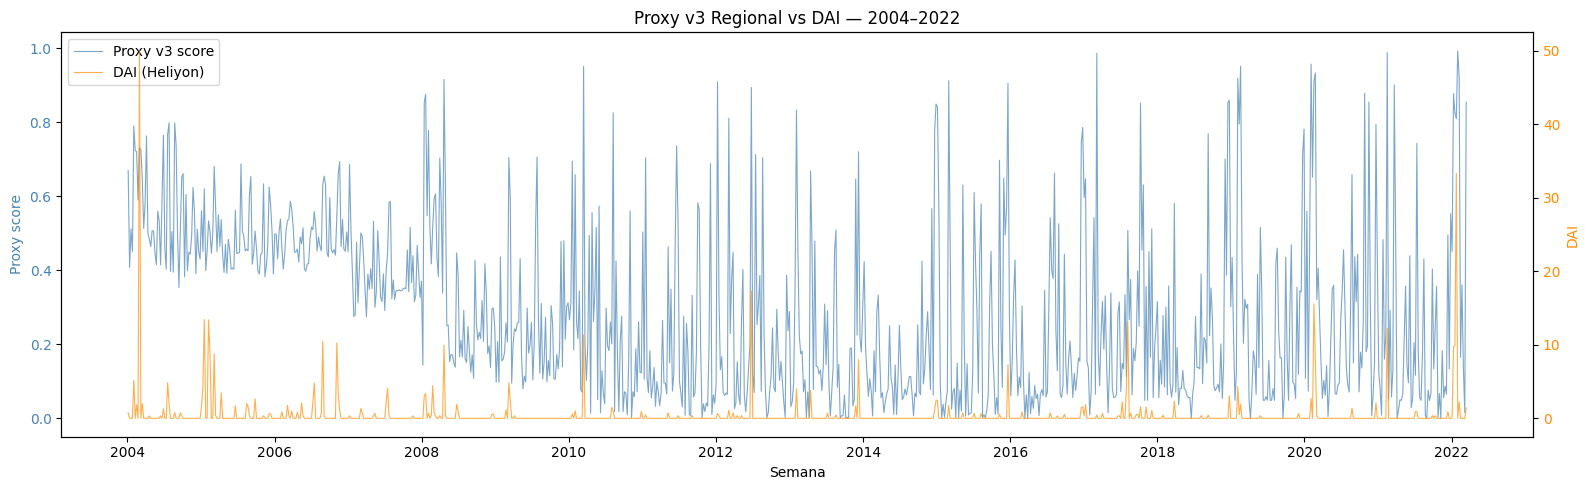

In [17]:

fig, ax1 = plt.subplots(figsize=(16, 5))

# Proxy score (eje izquierdo)
ax1.plot(validation["week_start"], validation["calima_proxy_score_regional"],
         color="steelblue", alpha=0.7, linewidth=0.8, label="Proxy v3 score")
ax1.set_ylabel("Proxy score", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# DAI (eje derecho)
ax2 = ax1.twinx()
ax2.plot(validation["week_start"], validation["DAI"],
         color="darkorange", alpha=0.7, linewidth=0.8, label="DAI (Heliyon)")
ax2.set_ylabel("DAI", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

ax1.set_xlabel("Semana")
ax1.set_title("Proxy v3 Regional vs DAI — 2004–2022")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
autosave_fig("C:/Users/fdora/RA_Career/Projects/climate_mortality/reports/ccaa/figures/proxy_V3_Regional_vs_DAI_04_22.png")
plt.show()

In [18]:
# Ver cobertura de air quality por isla en 2004-2008 vs resto
aq_coverage = weather_all.copy()
aq_coverage["year"] = pd.to_datetime(aq_coverage["week_start"]).dt.year

print("Coverage (n_days mean) por isla y período:")
print(
    weather_all.assign(year=pd.to_datetime(weather_all["week_start"]).dt.year)
    .assign(period=lambda x: x["year"].apply(lambda y: "2004-2008" if y <= 2008 else "2009-2025"))
    .groupby(["island", "period"])["coverage"]
    .mean()
    .round(2)
    .unstack()
)

Coverage (n_days mean) por isla y período:
period  2004-2008  2009-2025
island                      
ftv          0.99       0.99
gcan         1.00       0.97
gom          1.00       1.00
lpa          0.99       0.98
lzt          1.00       1.00
tfe          0.98       0.99


In [20]:
aq_list = []
for island, code in islands.items():
    ip = os.path.join(base, island)
    # Buscar el parquet 2004_2025 o 2005_2025 según isla
    candidates = [
        os.path.join(ip, "air_quality", f"weekly_{code}_2004_2025.parquet"),
        os.path.join(ip, "air_quality", f"weekly_{code}_2005_2025.parquet"),
        os.path.join(ip, "air_quality", f"weekly_{code}_2013_2025.parquet"),
    ]
    path = next((p for p in candidates if os.path.exists(p)), None)
    if path is None:
        print(f"⚠️ No encontrado: {island}")
        continue
    aq = pd.read_parquet(path)
    aq["island"] = code
    aq_list.append(aq)
    print(f"✅ {island}: {os.path.basename(path)}")

aq_all = pd.concat(aq_list, ignore_index=True)
aq_all["week_start"] = pd.to_datetime(aq_all["week_start"])
aq_all["period"] = aq_all["week_start"].dt.year.apply(lambda y: "2004-2008" if y <= 2008 else "2009-2025")

print("\nColumnas AQ:", aq_all.columns.tolist())

✅ tenerife: weekly_tfe_2004_2025.parquet
✅ gran_canaria: weekly_gcan_2005_2025.parquet
✅ lanzarote: weekly_lzt_2005_2025.parquet
✅ fuerteventura: weekly_ftv_2005_2025.parquet
✅ la_palma: weekly_lpa_2005_2025.parquet
✅ gomera: weekly_gom_2013_2025.parquet

Columnas AQ: ['week_start', 'year', 'PM10', 'PM2.5', 'SO2', 'NO2', 'O3', 'days_with_pm10', 'days_missing_pm10', 'island', 'n_days_week', 'n_obs_week', 'coverage_week', 'PM10_max_week', 'PM10_min_week', 'PM2.5_max_week', 'PM2.5_min_week', 'period']


In [21]:
print("PM10 null % por isla y período:")
print(
    aq_all.groupby(["island", "period"])["PM10"]
    .apply(lambda x: x.isnull().mean() * 100)
    .round(1)
    .unstack()
)

PM10 null % por isla y período:
period  2004-2008  2009-2025
island                      
ftv         100.0       11.6
gcan         74.8        0.0
gom           NaN        7.0
lpa         100.0        6.1
lzt          74.8        0.0
tfe          59.5        5.9


## Proxy v3 Regional — Limitación de cobertura PM10 (2004–2008)

### Problema identificado
Durante la validación del proxy v3 regional se identificó un comportamiento
anómalo en el período 2004–2008: el proxy score muestra valores elevados casi
continuos (baseline ~0.4–0.6), mientras que en 2009–2025 los picos son
episódicos y coherentes con eventos calima conocidos.

**Causa raíz:** cobertura de PM10 insuficiente en 2004–2008 por isla:
| Isla | PM10 nulls 2004–2008 | PM10 nulls 2009–2025 |
|------|----------------------|----------------------|
| tfe  | 59.5%                | 5.9%                 |
| gcan | 74.8%                | 0.0%                 |
| lzt  | 74.8%                | 0.0%                 |
| ftv  | 100%                 | 11.6%                |
| lpa  | 100%                 | 6.1%                 |
| gom  | n/a                  | 7.0%                 |

El script `build_calima_proxy.py` interpola linealmente los nulls de PM10.
En gaps de años enteros, esta interpolación produce valores artificiales que
inflan el proxy score de forma no representativa.

### Decisión
Se mantienen **dos versiones del master regional**:

1. `master_regional_2004_2025.parquet` — período completo con columna
   `proxy_reliable` (1 = 2009–2025, 0 = 2004–2008). Usar con precaución;
   excluir 2004–2008 del modelo de regresión.

2. `master_regional_2009_2025.parquet` — período truncado, proxy fiable
   en todas las islas. Dataset primario para modelado.

### Validación proxy v3 (solapamiento DAI 2004–2022)
- AUC vs DAI binario: **0.880** ✅ (criterio ≥ 0.80)
- Spearman vs DAI continuo: **0.487** ⚠️ (criterio ≥ 0.70 no cumplido)
- Interpretación: el criterio Spearman no es apropiado para una distribución
  con 84% ceros. El AUC es la métrica correcta para validación binaria.
  El proxy v3 es válido como clasificador calima sí/no.

In [22]:
# Opción 1: master truncado a 2009-2025
master_2009 = master[master["week_start"].dt.year >= 2009].copy().reset_index(drop=True)

# Opción 2: flag en master completo
master["proxy_reliable"] = (master["week_start"].dt.year >= 2009).astype(int)

print("Master completo (2004-2025):", master.shape)
print("Master truncado (2009-2025):", master_2009.shape)
print("\nProxy reliable distribution:")
print(master["proxy_reliable"].value_counts().sort_index())

# Exportar ambos
out_dir = r"C:\Users\fdora\RA_Career\Projects\climate_mortality\data\processed\provinces"

master.to_parquet(out_dir + r"\master_regional_2004_2025.parquet", index=False)
master_2009.to_parquet(out_dir + r"\master_regional_2009_2025.parquet", index=False)

print("\n✅ Exportados:")
print(f"  master_regional_2004_2025.parquet (con proxy_reliable flag)")
print(f"  master_regional_2009_2025.parquet (truncado limpio)")

Master completo (2004-2025): (1148, 15)
Master truncado (2009-2025): (887, 14)

Proxy reliable distribution:
proxy_reliable
0    261
1    887
Name: count, dtype: int64

✅ Exportados:
  master_regional_2004_2025.parquet (con proxy_reliable flag)
  master_regional_2009_2025.parquet (truncado limpio)


### Validacion 2


In [24]:
# Solapamiento master_2009 con DAI (hasta 2022)
validation_2009 = master_2009[master_2009["week_start"] <= "2022-03-14"].copy()
validation_2009 = validation_2009.merge(dai_weekly, on="week_start", how="left")
validation_2009["DAI"] = validation_2009["DAI"].fillna(0)
validation_2009["dai_binary"] = (validation_2009["DAI"] > 0).astype(int)

# Métricas
rho2, p_rho2 = spearmanr(validation_2009["calima_proxy_score_regional"], validation_2009["DAI"])
r_pb2, p_pb2 = pointbiserialr(validation_2009["dai_binary"], validation_2009["calima_proxy_score_regional"])
auc2 = roc_auc_score(validation_2009["dai_binary"], validation_2009["calima_proxy_score_regional"])

mask2 = validation_2009["DAI"] > 0
rho_ev2, p_ev2 = spearmanr(
    validation_2009.loc[mask2, "calima_proxy_score_regional"],
    validation_2009.loc[mask2, "DAI"]
)

print(f"=== VALIDACIÓN PROXY v3 — 2009–2022 ===")
print(f"Semanas totales:        {len(validation_2009)}")
print(f"Semanas con evento DAI: {mask2.sum()}")
print(f"\nSpearman rho (all):     {rho2:.3f}  (p={p_rho2:.4f})")
print(f"Point-biserial r:       {r_pb2:.3f}  (p={p_pb2:.4f})")
print(f"AUC:                    {auc2:.3f}")
print(f"Spearman (eventos):     {rho_ev2:.3f}  (p={p_ev2:.4f})")
print(f"\nAUC ≥ 0.80 → {'✅ PASS' if auc2 >= 0.80 else '❌ FAIL'}")
print(f"Spearman ≥ 0.70 → {'✅ PASS' if rho2 >= 0.70 else '❌ FAIL'}")

=== VALIDACIÓN PROXY v3 — 2009–2022 ===
Semanas totales:        689
Semanas con evento DAI: 84

Spearman rho (all):     0.457  (p=0.0000)
Point-biserial r:       0.588  (p=0.0000)
AUC:                    0.900
Spearman (eventos):     0.568  (p=0.0000)

AUC ≥ 0.80 → ✅ PASS
Spearman ≥ 0.70 → ❌ FAIL


In [25]:
validation_0408 = master[
    (master["week_start"].dt.year < 2009) & 
    (master["week_start"] <= "2022-03-14")
].copy()
validation_0408 = validation_0408.merge(dai_weekly, on="week_start", how="left")
validation_0408["DAI"] = validation_0408["DAI"].fillna(0)
validation_0408["dai_binary"] = (validation_0408["DAI"] > 0).astype(int)

mask_0408 = validation_0408["DAI"] > 0

rho_0408, p_0408 = spearmanr(validation_0408["calima_proxy_score_regional"], validation_0408["DAI"])
auc_0408 = roc_auc_score(validation_0408["dai_binary"], validation_0408["calima_proxy_score_regional"])
rho_ev_0408, _ = spearmanr(
    validation_0408.loc[mask_0408, "calima_proxy_score_regional"],
    validation_0408.loc[mask_0408, "DAI"]
)

print(f"=== VALIDACIÓN PROXY v3 — 2004–2008 ===")
print(f"Semanas totales:        {len(validation_0408)}")
print(f"Semanas con evento DAI: {mask_0408.sum()}")
print(f"\nSpearman rho (all):     {rho_0408:.3f}  (p={p_0408:.4f})")
print(f"AUC:                    {auc_0408:.3f}")
print(f"Spearman (eventos):     {rho_ev_0408:.3f}")
print(f"\nAUC ≥ 0.80 → {'✅ PASS' if auc_0408 >= 0.80 else '❌ FAIL'}")

=== VALIDACIÓN PROXY v3 — 2004–2008 ===
Semanas totales:        261
Semanas con evento DAI: 67

Spearman rho (all):     0.485  (p=0.0000)
AUC:                    0.817
Spearman (eventos):     0.167

AUC ≥ 0.80 → ✅ PASS
